# Example: solving the forward problem

Solving the 2D wave equation using ODIL on a grid $\hat{u}$ involves minimising the functional 

$$\mathcal{L}(\hat{u}) =
    \sum_{(i,\, n) \in \Omega} 
    \left( 
        \frac{\partial^2 \hat{u}}{\partial t^2} -  c^2\nabla^2\hat{u} - f
    \right)^2 
    + \sum_{(i,\, n) \in \Gamma} 
        \left(
            \hat{u} - \hat{g}
        \right)^2,
$$

where $f$ is a source term, and $g$ are the discretised boundary/ initial conditions.

In this example, we will solve an example for which $x = \Delta x i,\, i = 0, 1, 2, \cdots, I$, $y = \Delta y j,\, j = 0, 1, 2, \cdots, J$ for which $I = J = 125$. Let's do so over a domain $x, y \in [0.0, 1.0]$.

We can represent this domain using a `Grid` object:

In [1]:
from src.grid import Grid
grid = Grid(interior_shape=(125, 125), interior_extent=((0.0, 1.0), (0.0, 1.0)))

Let's take a look at what parameters this grid represents:

In [2]:
print(grid.summary)

Grid interior 125x125 -> total 145x145 (PML p=10),
nt=621, dx=0.0081m, dy=0.0081m,
dt=0.0030 s, cfl@c_ref=0.800,
interior x in [0.00, 1.00]m,
y in [0.00, 1.00]m,
total x in [-0.08, 1.08]m,
total y in [-0.08, 1.08]m


The time discretisation is computed automatically from the spatial spec according to the CFL condition.

The `Grid` class also computes PML boundary absorpiton profiles and bounds the grid with additional nodes to enforce them. Let's look at this more.

<Axes: title={'center': 'PML absorption $\\sigma_x + \\sigma_y$'}, xlabel='x [m]', ylabel='y [m]'>

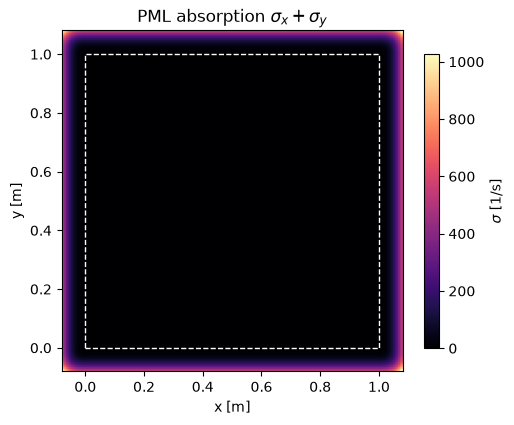

In [3]:
grid.plot_absorption_profile()

From a `Grid`, we can start to build the other components of the problem. First, let's build a velocity model.

<Axes: title={'center': 'c(x, y) [shepp_logan]'}, xlabel='x [m]', ylabel='y [m]'>

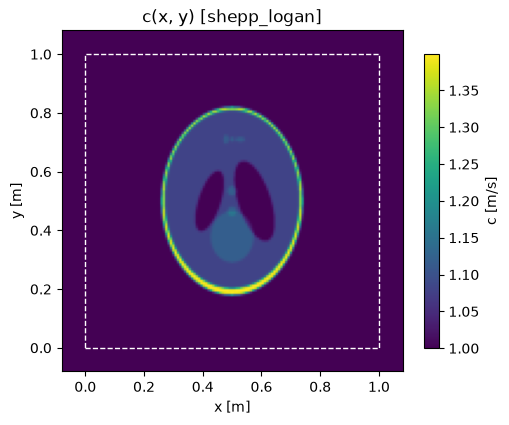

In [4]:
from src.models import VelocityModel

model = VelocityModel(grid=grid, profile='shepp_logan')
model.show()

Amplitude data can be represented by a `Wavefield` object:

In [5]:
from src.wavefield import Wavefield
wavefield = Wavefield(grid=grid, init_wavespeed=model.c)

Our data have 2 spatial dimensions and 1 temporal dimension, so to visualise them we must choose a plane and a slice index:

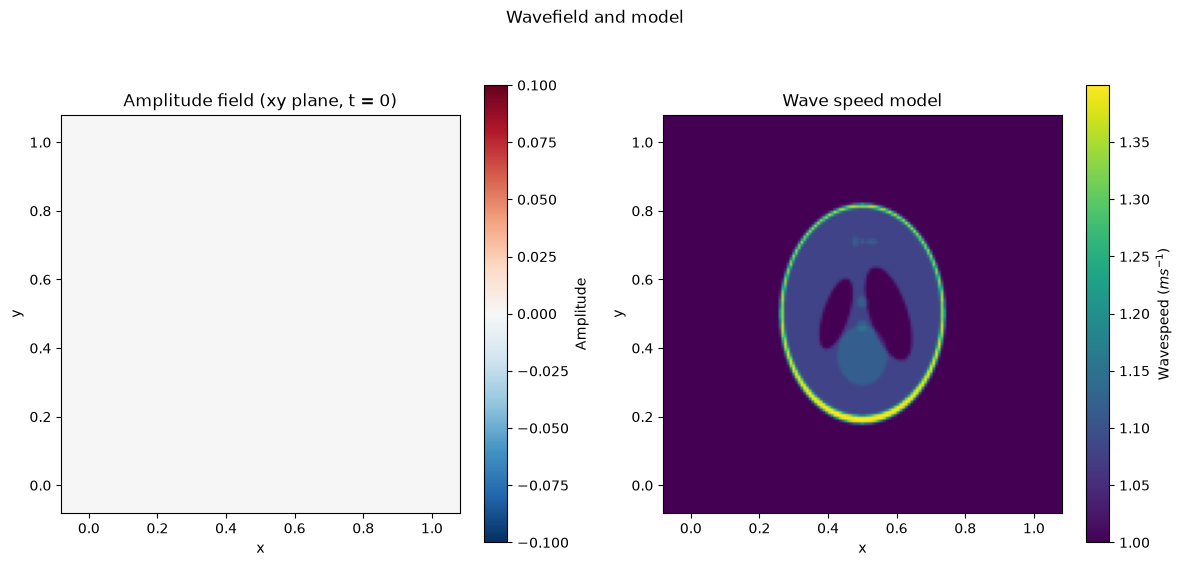

In [6]:
wavefield.show(idx=0)

Amplitude data is initialised to zero by default.

To drive wave propagation, we need a source term. This can be provided by an `AcquisitionGeometry`, which also places receivers on the domain for if we want to include a data loss term (to drive an inverse solve). Since this package is aimed at modelling waves in the brain, sources and receivers are placed in a ring by default, so we must specify the ring center alongside the number of sources and receivers and peak frequency.

In [21]:
from src.geometry import AcquisitionGeometry
geometry = AcquisitionGeometry(grid=grid, n_sources=10, n_receivers=20, ring_center=(0.5, 0.5), f0=10.0)

<Axes: title={'center': 'acquisition on shepp_logan'}, xlabel='x [m]', ylabel='y [m]'>

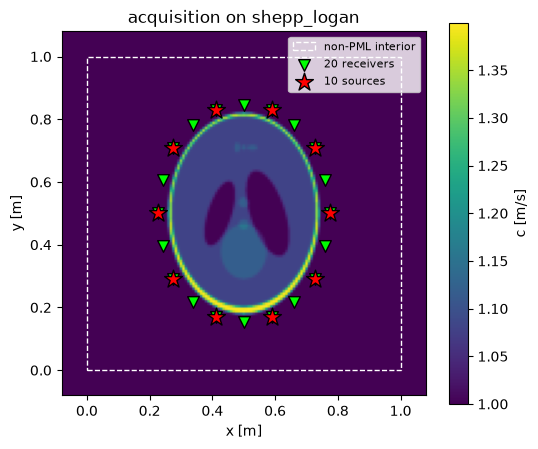

In [22]:
geometry.show(model)

We can now move towards the physics of our problem. The discretisation scheme is controlled by operators of type `Operator` and there are a few options, but thankfully we can just specify the desired method order in time and space to a `WaveEquation` object and it will construct our operators along with objects that apply initial and boundary conditions. 

In [25]:
from src.operator import WaveEquation
wave_eq = WaveEquation(wavefield=wavefield, time_order=2, space_order=2)

To form a loss function, we can use a `ForwardLoss` object that should be configured using a `LossConfig`

In [ ]:
from src.loss import LossConfig, ForwardLoss